In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
# Lets create synthetic data points
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_redundant=0,random_state=22,n_clusters_per_class=1)

In [49]:
X

array([[0.30327986, 0.48139074],
       [0.73969246, 0.91956165],
       [1.19664626, 1.11237246],
       ...,
       [1.95936248, 1.37677919],
       [0.26272263, 0.32409563],
       [1.37999245, 1.04924617]], shape=(1000, 2))

In [50]:
y

array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,

<Axes: xlabel='0', ylabel='1'>

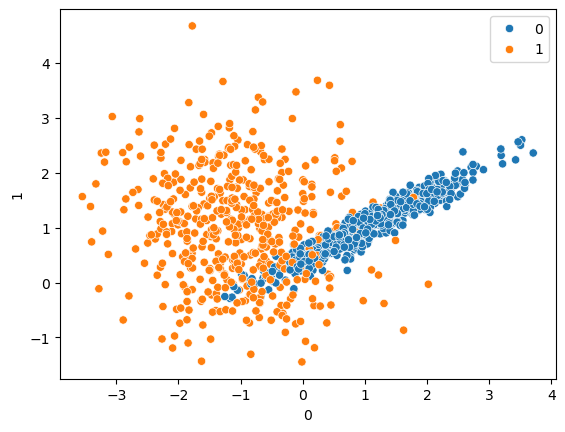

In [51]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [53]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

## For RBF Kernel

In [52]:
from sklearn.svm import SVC
svc=SVC()

In [54]:
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)

In [56]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       119
           1       0.95      0.91      0.93       131

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250

[[113   6]
 [ 12 119]]


In [71]:
svc.intercept_

array([1.18488954])

## For Linear Kernel

In [57]:
linear=SVC(kernel='linear')
linear.fit(X_train,y_train)
y_pred_linear=linear.predict(X_test)
print(classification_report(y_test,y_pred_linear))
print(confusion_matrix(y_test,y_pred_linear))


              precision    recall  f1-score   support

           0       0.85      0.92      0.89       119
           1       0.93      0.85      0.89       131

    accuracy                           0.89       250
   macro avg       0.89      0.89      0.89       250
weighted avg       0.89      0.89      0.89       250

[[110   9]
 [ 19 112]]


In [69]:
linear.coef_,linear.intercept_

(array([[-1.78475955,  0.8446774 ]]), array([-0.69688647]))

## For Polynomial Kernel

In [58]:
poly=SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred_poly=poly.predict(X_test)
print(classification_report(y_test,y_pred_poly))
print(confusion_matrix(y_test,y_pred_poly)) 

              precision    recall  f1-score   support

           0       0.81      0.98      0.89       119
           1       0.98      0.79      0.87       131

    accuracy                           0.88       250
   macro avg       0.89      0.88      0.88       250
weighted avg       0.90      0.88      0.88       250

[[117   2]
 [ 28 103]]


In [68]:
poly.intercept_

array([-0.82443827])

## For Sigmoid Kernel

In [59]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)
y_pred_sigmoid=sigmoid.predict(X_test)
print(classification_report(y_test,y_pred_sigmoid))
print(confusion_matrix(y_test,y_pred_sigmoid))

              precision    recall  f1-score   support

           0       0.72      0.79      0.76       119
           1       0.79      0.73      0.76       131

    accuracy                           0.76       250
   macro avg       0.76      0.76      0.76       250
weighted avg       0.76      0.76      0.76       250

[[94 25]
 [36 95]]


In [67]:
sigmoid.intercept_

array([-6.98382885])

## Hyper Parameter Tuning with SVC

In [61]:
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}

In [63]:
grid=GridSearchCV(SVC(),param_grid,refit=True,verbose=3,cv=5)

In [64]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.887 total time=   0.1s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [65]:
grid.best_params_

{'C': 100, 'gamma': 1, 'kernel': 'rbf'}

In [66]:
y_pred_grid=grid.predict(X_test)
print(classification_report(y_test,y_pred_grid))
print(confusion_matrix(y_test,y_pred_grid))



              precision    recall  f1-score   support

           0       0.91      0.97      0.93       119
           1       0.97      0.91      0.94       131

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[115   4]
 [ 12 119]]


## SVM Kernels Indepth Intuition and Practical Explanation

In [72]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-5,5,100)
y=np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,x])

In [73]:
x1=np.linspace(-5,5,100)
y1=np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

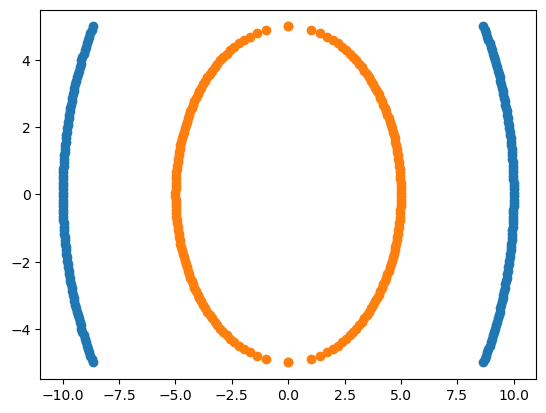

In [74]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [79]:
import pandas as pd
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df=pd.concat([df1, df2], ignore_index=True)
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [80]:
# Independent and dependent features
X=df.iloc[:,:2]
y=df.Y

In [ ]:
# spliting the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


## Polynomial Kernel

In [81]:
df['X1_square']=df['X1']**2
df['X2_square']=df['X2']**2
df['X1_X2']=df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_square,X2_square,X1_X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [ ]:
X=df[['X1','X2','X1_square','X2_square','X1_X2']]
y=df['Y']

In [82]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


In [83]:
X_train

,X1,X2
247,4.993619,-0.252525
110,-9.169553,-3.989899
16,9.410082,-3.383838
66,9.860133,1.666667
153,-9.993749,0.353535
...,...,...
71,9.761334,2.171717
106,-8.982945,-4.393939
270,4.551063,2.070707
348,-4.997704,0.151515


In [84]:
import plotly.express as px
px.scatter_3d(df,x='X1',y='X2',z='X1_X2',color='Y')

In [86]:
px.scatter_3d(df,x='X1_square',y='X2_square',z='X1_X2',color='Y')

In [90]:
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='linear')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.47


In [91]:
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='poly')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.69


In [ ]:
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='rbf')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
print(accuracy_score(y_test,y_pred))

1.0


In [94]:
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='sigmoid')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.59
